# Ejercicio 1 — Una variable, otra variable, o ambas
**Universidad El Bosque — Programa de Matemáticas y Estadística — Introducción al Machine Learning — Semestre 2026-2**

En este ejercicio se comparan tres regresiones lineales con intercepto sobre `experimento_1.csv`: usando solo `x1`, solo `x2` y ambas variables. En todos los casos el criterio de comparación es el riesgo empírico con pérdida cuadrática,
$$\hat R_S(h)=\frac1n\sum_{i=1}^n\big(y_i-h(x_i)\big)^2 ,$$
calculado sobre los mismos datos con los que se ajusta el modelo. Todo el código de carga, ajuste y cálculo de riesgos vive en `src/lista4/` y aquí solo se invoca.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import sys

sys.path.append("../src")

# Formato numérico uniforme para las tablas
pd.set_option("display.float_format", lambda v: f"{v:.6f}")

from lista4 import (cargar_datos, resumen_regresion, tabla_resumen_regresion,
                    correlacion, grafica_dispersion_con_recta)

df = cargar_datos("experimento_1")
print(df.shape)
df.head()

(300, 3)


,x1,x2,y
0,0.304717,1.727350,1.429562
1,-1.039984,-1.533861,-3.697491
2,0.750451,0.863828,3.525801
3,0.940565,-0.328525,2.194107
4,-1.951035,-0.061324,-6.489721


## (a) Tabla de los tres modelos

Cada fila es un modelo; las columnas `coef_*` quedan vacías (`NaN`) cuando el modelo no usa esa variable.

In [3]:
especificaciones = {
    "x1 → y":       ["x1"],
    "x2 → y":       ["x2"],
    "(x1, x2) → y": ["x1", "x2"],
}
tabla_1 = tabla_resumen_regresion(df, especificaciones)
tabla_1

,Intercepto,coef_x1,coef_x2,Riesgo empírico
x1 → y,-0.082506,2.920460,NaN,1.020069
x2 → y,-0.202971,NaN,-0.044049,8.374587
"(x1, x2) → y",-0.083790,2.925130,-0.131194,1.002351


La tabla ya permite una primera lectura: el modelo que solo usa `x1` alcanza un riesgo empírico cercano a 1.02, mientras que el que solo usa `x2` queda en torno a 8.37, es decir, unas ocho veces peor. El modelo con ambas variables mejora apenas un poco al de `x1` (1.002 frente a 1.020), y el coeficiente de `x1` casi no se mueve al incluir `x2` (de 2.920 a 2.925). Las correlaciones del siguiente punto explican por qué.

## (b) Correlaciones

In [4]:
correlaciones = pd.Series({
    "corr(x1, y)":  correlacion(df, "x1", "y"),
    "corr(x2, y)":  correlacion(df, "x2", "y"),
    "corr(x1, x2)": correlacion(df, "x1", "x2"),
}, name="Correlación de Pearson")
correlaciones.to_frame()

,Correlación de Pearson
"corr(x1, y)",0.937136
"corr(x2, y)",-0.015450
"corr(x1, x2)",0.032563


`x1` está fuertemente correlacionada con `y` (≈ 0.937), mientras que `x2` prácticamente no tiene relación lineal con `y` (≈ −0.015). Además, `x1` y `x2` casi no se relacionan entre sí (≈ 0.033). Esto último es lo que hace que agregar `x2` al modelo no altere el coeficiente de `x1`: cuando dos predictores son casi ortogonales, cada uno aporta su información por separado y el coeficiente de uno no necesita "compensar" al otro. Y como `x2` casi no explica nada de `y`, el descenso del riesgo al incluirla es mínimo.

## (c) Gráficas de $y$ contra $x_1$ y contra $x_2$ con su recta ajustada

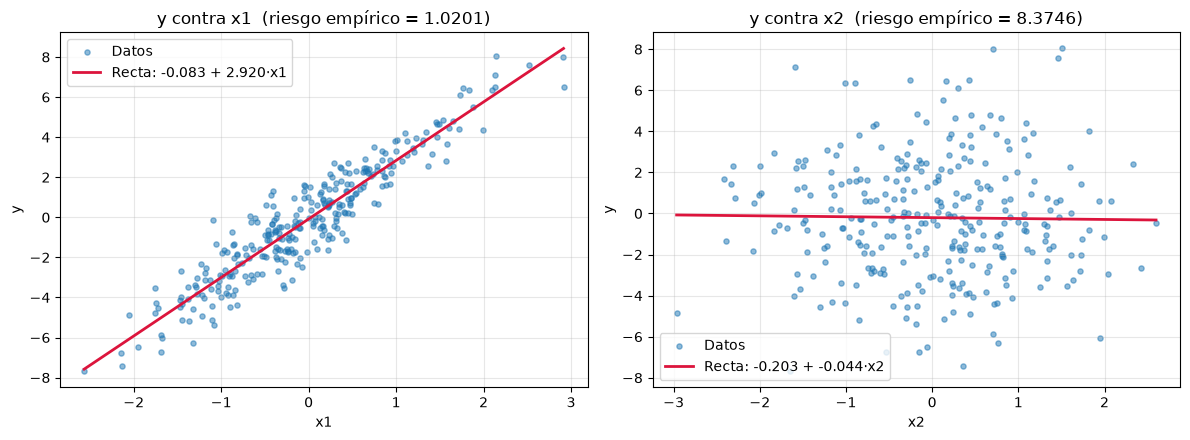

In [5]:
res_x1 = resumen_regresion(df, ["x1"])
res_x2 = resumen_regresion(df, ["x2"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
grafica_dispersion_con_recta(df, "x1", res_x1, ax=axes[0])
grafica_dispersion_con_recta(df, "x2", res_x2, ax=axes[1])
plt.tight_layout()
plt.show()

En la gráfica de la izquierda la nube de puntos sigue claramente una recta creciente y la recta ajustada la atraviesa por el centro. En la de la derecha la nube no muestra tendencia: la recta ajustada es casi horizontal y los puntos se reparten con gran dispersión a su alrededor, lo que se traduce en el riesgo empírico mucho más alto.

## (d) ¿Qué variable conservar?

In [7]:
riesgos = {"x1": res_x1["riesgo"], "x2": res_x2["riesgo"]}
conservar = min(riesgos, key=riesgos.get)
print(f"Riesgo empírico solo con x1: {riesgos['x1']:.4f}")
print(f"Riesgo empírico solo con x2: {riesgos['x2']:.4f}")
print(f"Variable a conservar (menor riesgo empírico): {conservar}")

Riesgo empírico solo con x1: 1.0201
Riesgo empírico solo con x2: 8.3746
Variable a conservar (menor riesgo empírico): x1


**Respuesta.** Se conservaría **`x1`**, porque el modelo de una sola variable que la usa tiene el menor riesgo empírico (≈ 1.020 frente a ≈ 8.375 de `x2`). Este resultado es coherente con las correlaciones del punto (b), y además agregar `x2` después de `x1` solo reduce el riesgo en unas 0.018 unidades.